# **AI-Based Multi-Label Prediction of Diabetes Complications**


## Data Collection

In [5]:
import pandas as pd


df = pd.read_csv("/home/sami/Diabetes Complication Risk Prediction Model/data/diabetic_data.csv")
df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Data Cleaning

In [ ]:
def replace_missing_values(df):
    df = df.replace("?", pd.NA)
    return df

In [11]:
df = replace_missing_values(df)
null_percent = df.isnull().sum() * 100 / len(df)
print("Percentage of Null Values in Each Column:")
print(null_percent)
    

Percentage of Null Values in Each Column:
encounter_id                 0.000000
patient_nbr                  0.000000
race                         2.233555
gender                       0.000000
age                          0.000000
weight                      96.858479
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                  39.557416
medical_specialty           49.082208
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.020636
diag_2                       0.351787
diag_3                       1.398306
number_diagnoses             0.000000
max_glu_serum               94.746772
A1Cresult                   83.277322
metformin                    0.000000
repaglin

In [12]:
def clean_dataset(df):

    # Replace '?' with NaN
    df = replace_missing_values(df)

    # Drop ID columns
    df = df.drop(columns=["encounter_id", "patient_nbr"])

    # Drop columns with excessive missing values
    df = df.drop(columns=["weight", "payer_code", "medical_specialty"])
    # Weight Column has 96% missing values, 
    # Payer code has 40% missing values, 
    # Medical specialty has 50% missing values

    # Fill race
    df["race"] = df["race"].fillna("Unknown")

    # Fill diagnosis columns
    df["diag_1"] = df["diag_1"].fillna("0")
    df["diag_2"] = df["diag_2"].fillna("0")
    df["diag_3"] = df["diag_3"].fillna("0")

    # Fill lab test columns as "None" since they are 
    # categorical and missing values indicate that the test was not performed
    df["max_glu_serum"] = df["max_glu_serum"].fillna("None")
    df["A1Cresult"] = df["A1Cresult"].fillna("None")

    return df

In [13]:
cleaned_df = clean_dataset(df)
print("Percentage of Null Values in Each Column for Cleaned Dataset:")
print(cleaned_df.isnull().sum() * 100 / len(cleaned_df))

Percentage of Null Values in Each Column for Cleaned Dataset:
race                        0.0
gender                      0.0
age                         0.0
admission_type_id           0.0
discharge_disposition_id    0.0
admission_source_id         0.0
time_in_hospital            0.0
num_lab_procedures          0.0
num_procedures              0.0
num_medications             0.0
number_outpatient           0.0
number_emergency            0.0
number_inpatient            0.0
diag_1                      0.0
diag_2                      0.0
diag_3                      0.0
number_diagnoses            0.0
max_glu_serum               0.0
A1Cresult                   0.0
metformin                   0.0
repaglinide                 0.0
nateglinide                 0.0
chlorpropamide              0.0
glimepiride                 0.0
acetohexamide               0.0
glipizide                   0.0
glyburide                   0.0
tolbutamide                 0.0
pioglitazone                0.0
rosiglitaz

In [14]:
cleaned_df.head()
cleaned_df.to_csv("/home/sami/Diabetes Complication Risk Prediction Model/data/cleaned_diabetic_data.csv", index=False)

## Data Preprocessing

In [42]:
import pandas as pd
from sklearn.preprocessing import StandardScaler


def load_data(path):
    return pd.read_csv(path)


def convert_age(age_range):
    age_range = age_range.strip("[]()")
    lower, upper = age_range.split("-")
    return (int(lower) + int(upper)) / 2


from sklearn.preprocessing import StandardScaler
import pandas as pd

def preprocess_dataset(input_path, output_path):

    df = load_data(input_path)

    # Convert age ranges to numeric
    df["age"] = df["age"].apply(convert_age)

    # Encode gender
    df["gender"] = df["gender"].map({
        "Male": 1,
        "Female": 0
    })

    # Encode binary variables
    df["change"] = df["change"].map({"Ch": 1, "No": 0})
    df["diabetesMed"] = df["diabetesMed"].map({"Yes": 1, "No": 0})

    # Encode medication columns
    med_map = {
        "No": 0,
        "Steady": 1,
        "Up": 2,
        "Down": 3
    }

    medication_cols = [
        "metformin","repaglinide","nateglinide","chlorpropamide",
        "glimepiride","acetohexamide","glipizide","glyburide",
        "tolbutamide","pioglitazone","rosiglitazone","acarbose",
        "miglitol","troglitazone","tolazamide","examide",
        "citoglipton","insulin","glyburide-metformin",
        "glipizide-metformin","glimepiride-pioglitazone",
        "metformin-rosiglitazone","metformin-pioglitazone"
    ]

    for col in medication_cols:
        df[col] = df[col].map(med_map).fillna(0)

    # Ensure lab-test columns explicitly include "None"
    df["max_glu_serum"] = df["max_glu_serum"].fillna("None")
    df["A1Cresult"] = df["A1Cresult"].fillna("None")

    # One-hot encode categorical columns (including "None")
    categorical_cols = [
        "race",
        "max_glu_serum",
        "A1Cresult"
    ]

    df = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

    # Convert booleans to integers
    df = df.replace({True: 1, False: 0})

    # Scale numeric columns
    numeric_cols = [
        "age",
        "time_in_hospital",
        "num_lab_procedures",
        "num_procedures",
        "num_medications",
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
        "number_diagnoses"
    ]

    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    df.to_csv(output_path, index=False)

    print("Preprocessed dataset saved.")

    return scaler  # Return the scaler for later use


if __name__ == "__main__":

   scaler = preprocess_dataset(
        "/home/sami/Diabetes Complication Risk Prediction Model/data/cleaned_diabetic_data.csv",
        "/home/sami/Diabetes Complication Risk Prediction Model/data/diabetes_processed.csv"
    )

Preprocessed dataset saved.


## Feature Engineering

In [22]:
import pandas as pd



def safe_float(value):
    try:
        return float(value)
    except:
        return None


def classify_complications(row):

    diagnoses = [
        row["diag_1"],
        row["diag_2"],
        row["diag_3"]
    ]

    cardiovascular = 0
    kidney = 0
    neuropathy = 0

    for diag in diagnoses:

        diag_val = safe_float(diag)

        if diag_val is None:
            continue

        # Cardiovascular
        if 390 <= diag_val <= 459:
            cardiovascular = 1

        # Kidney disease
        if 580 <= diag_val <= 629:
            kidney = 1

        # Neuropathy
        if int(diag_val) == 357 or str(diag).startswith("250.6"):
            neuropathy = 1

    return pd.Series([cardiovascular, kidney, neuropathy])


def create_labels(df):

    df[
        [
            "cardiovascular_complication",
            "kidney_complication",
            "neuropathy_complication",
        ]
    ] = df.apply(classify_complications, axis=1)

    return df

def drop_labels(df):

    features_to_drop = [
        "diag_1",
        "diag_2",
        "diag_3"
    ]

    df = df.drop(columns=features_to_drop)
    df = df.drop(columns=["readmitted"])
    return df


def run_feature_engineering(input_path, output_path):

    df = load_data(input_path)

    df = create_labels(df)

    df = drop_labels(df)

    df.to_csv(output_path, index=False)

    print("Feature engineering complete.")


if __name__ == "__main__":

    run_feature_engineering(
        "/home/sami/Diabetes Complication Risk Prediction Model/data/diabetes_processed.csv",
        "/home/sami/Diabetes Complication Risk Prediction Model/data/diabetes_final.csv"
    )

Feature engineering complete.


## Exploratory Data Analysis

### Import Libraries

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

### Load Dataset

In [65]:
df = pd.read_csv("../data/diabetes_final.csv")

numeric_cols = [
    "age",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 55)


,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,max_glu_serum_>300,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm,cardiovascular_complication,kidney_complication,neuropathy_complication
0,0.0,-3.824600,6,25,1,-1.137649,-0.106517,-0.785398,-1.848268,-0.291461,...,0,1,0,0,0,1,0,0,0,0
1,0.0,-3.197277,1,1,7,-0.467653,0.808384,-0.785398,0.243390,-0.291461,...,0,1,0,0,0,1,0,0,0,0
2,0.0,-2.569954,1,1,7,-0.802651,-1.631351,2.145781,-0.371804,1.286748,...,0,1,0,0,0,1,0,0,0,0
3,1.0,-1.942632,1,1,7,-0.802651,0.045967,-0.199162,-0.002688,-0.291461,...,0,1,0,0,0,1,0,1,0,0
4,1.0,-1.315309,1,1,7,-1.137649,0.401761,-0.785398,-0.986997,-0.291461,...,0,1,0,0,0,1,0,0,0,0


### Dataset Overview

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 55 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   gender                       101763 non-null  float64
 1   age                          101766 non-null  float64
 2   admission_type_id            101766 non-null  int64  
 3   discharge_disposition_id     101766 non-null  int64  
 4   admission_source_id          101766 non-null  int64  
 5   time_in_hospital             101766 non-null  float64
 6   num_lab_procedures           101766 non-null  float64
 7   num_procedures               101766 non-null  float64
 8   num_medications              101766 non-null  float64
 9   number_outpatient            101766 non-null  float64
 10  number_emergency             101766 non-null  float64
 11  number_inpatient             101766 non-null  float64
 12  number_diagnoses             101766 non-null  float64
 13  metformin 

In [45]:
df.describe()

,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,max_glu_serum_>300,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm,cardiovascular_complication,kidney_complication,neuropathy_complication
count,101763.000000,1.017660e+05,101766.000000,101766.000000,101766.000000,1.017660e+05,1.017660e+05,1.017660e+05,1.017660e+05,1.017660e+05,...,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,0.462398,-4.468559e-16,2.024006,3.715642,5.754437,8.043406e-17,1.139482e-16,-4.245131e-17,-1.340568e-16,4.468559e-17,...,0.012421,0.947468,0.025519,0.037458,0.080734,0.832773,0.049034,0.576538,0.170096,0.031513
std,0.498587,1.000005e+00,1.445403,5.280166,4.064081,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,...,0.110754,0.223099,0.157697,0.189883,0.272428,0.373180,0.215940,0.494110,0.375719,0.174702
min,0.000000,-3.824600e+00,1.000000,1.000000,1.000000,-1.137649e+00,-2.139630e+00,-7.853977e-01,-1.848268e+00,-2.914615e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,-6.879862e-01,1.000000,1.000000,1.000000,-8.026506e-01,-6.147950e-01,-7.853977e-01,-7.409197e-01,-2.914615e-01,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,-6.066351e-02,1.000000,1.000000,7.000000,-1.326548e-01,4.596660e-02,-1.991621e-01,-1.257264e-01,-2.914615e-01,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,5.666592e-01,3.000000,4.000000,7.000000,5.373411e-01,7.067282e-01,3.870736e-01,4.894670e-01,-2.914615e-01,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.821305e+00,8.000000,28.000000,25.000000,3.217324e+00,4.518815e+00,2.732016e+00,7.994826e+00,3.285094e+01,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Class Distribution

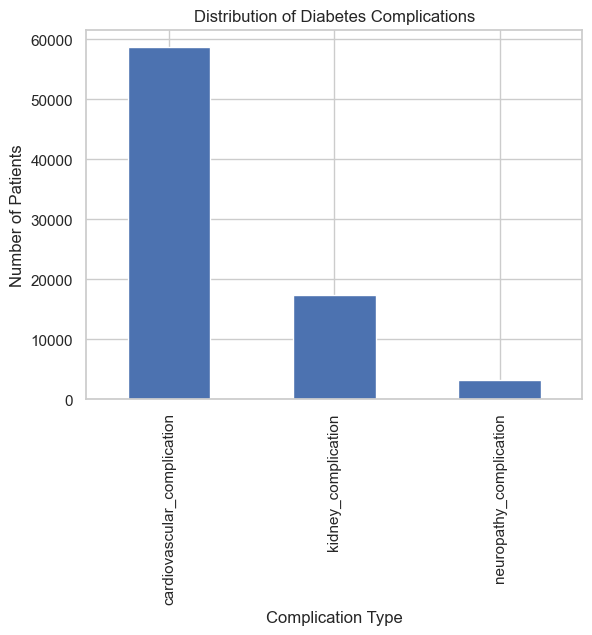

<Figure size 640x480 with 0 Axes>

In [66]:
labels = [
    "cardiovascular_complication",
    "kidney_complication",
    "neuropathy_complication"
]

df[labels].sum().plot(kind="bar")

plt.title("Distribution of Diabetes Complications")
plt.ylabel("Number of Patients")
plt.xlabel("Complication Type")
plt.show()
plt.savefig("../report/figures/class_distribution.png")

### Age Distribution

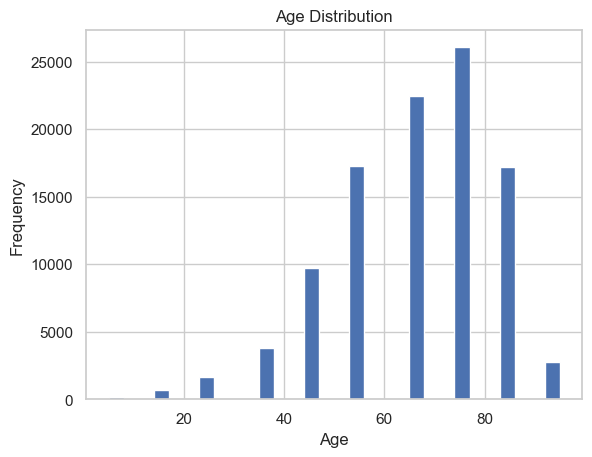

<Figure size 640x480 with 0 Axes>

In [55]:
age_unscaled = scaler.inverse_transform(df[numeric_cols])[:, numeric_cols.index("age")]

plt.hist(age_unscaled, bins=30)


plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
plt.savefig("../report/figures/age_distribution.png")

### Correlation Heatmap

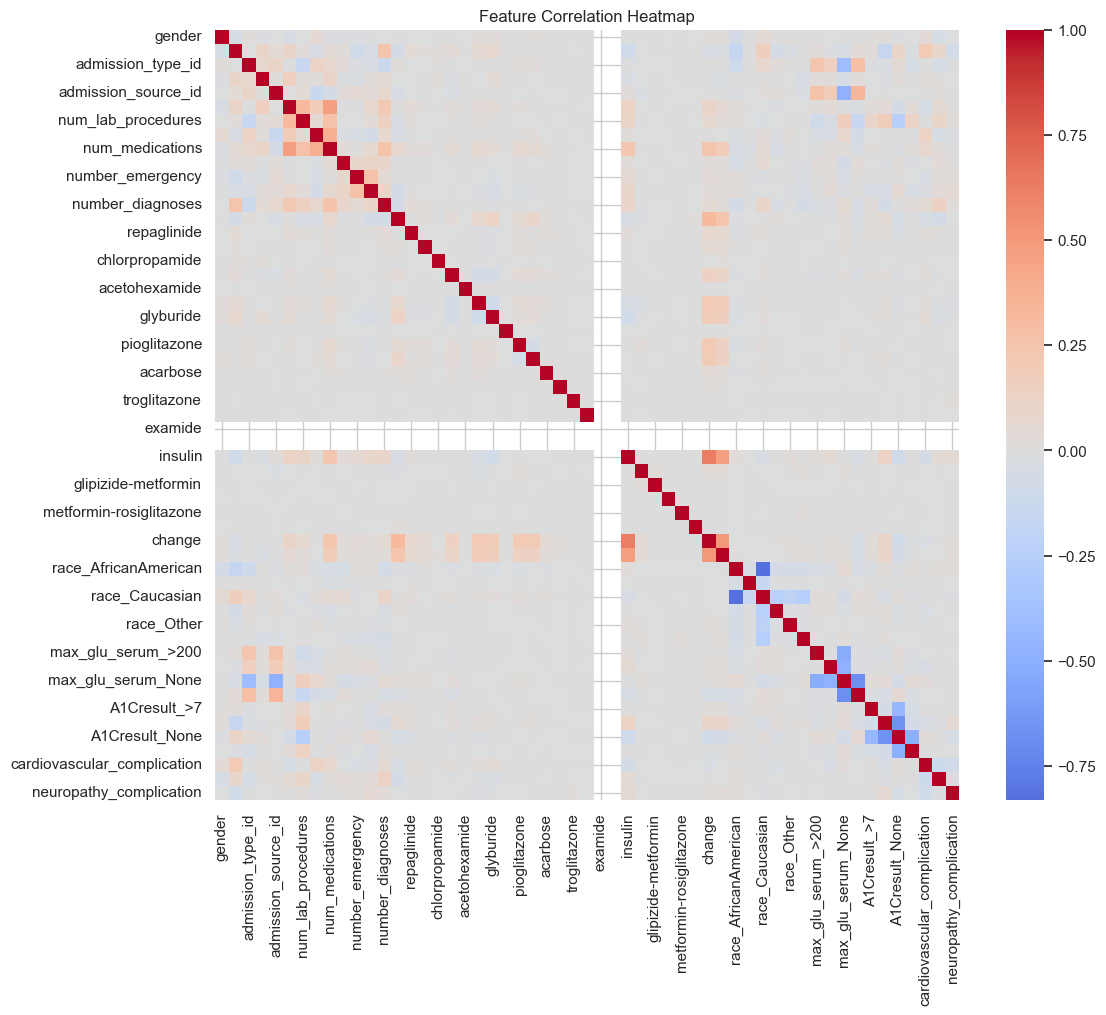

<Figure size 640x480 with 0 Axes>

In [56]:
plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()
plt.savefig("../report/figures/feature_correlation.png")

### Hospital Visit Statistics

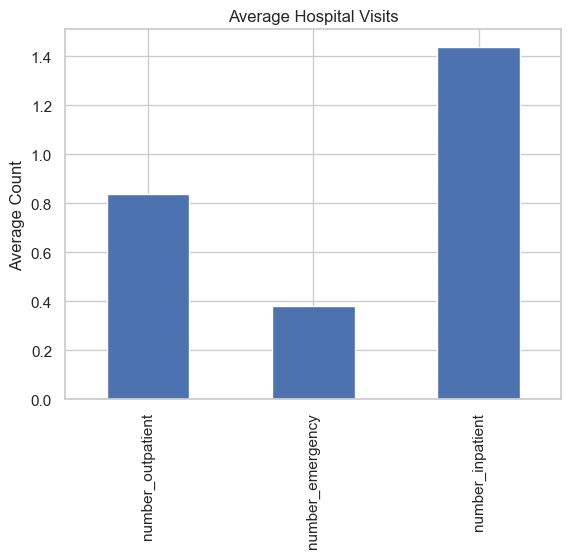

<Figure size 640x480 with 0 Axes>

In [57]:
visit_cols = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

for col in visit_cols:
    df[col] = scaler.inverse_transform(df[numeric_cols])[:, numeric_cols.index(col)]

df[visit_cols].mean().plot(kind="bar")

plt.title("Average Hospital Visits")
plt.ylabel("Average Count")
plt.show()
plt.savefig("../report/figures/average_visits.png")

### Medication Usage

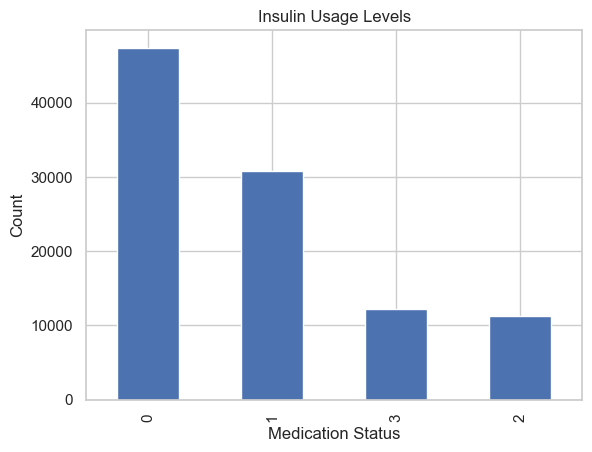

<Figure size 640x480 with 0 Axes>

In [58]:
df["insulin"].value_counts().plot(kind="bar")

plt.title("Insulin Usage Levels")
plt.xlabel("Medication Status")
plt.ylabel("Count")
plt.show()
plt.savefig("../report/figures/insulin_usage.png")

### Complication Relationships

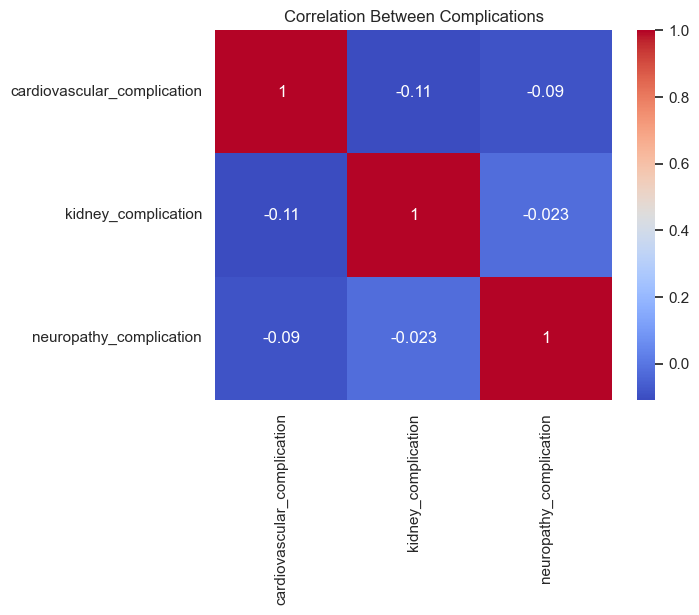

<Figure size 640x480 with 0 Axes>

In [60]:
sns.heatmap(
    df[labels].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Complications")
plt.show()
plt.savefig("../report/figures/complication_correlation.png")
